In [ ]:
## Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pyproj
import xarray as xr

In [ ]:
# Load the two datasets (Band 13 and Band 7)
file_band13_path = "/content/OR_ABI-L1b-RadC-M3C07_G16_s20183122357181_e20183122359565_c20183130000001.nc"
file_band7_path = "/content/OR_ABI-L1b-RadC-M3C13_G16_s20183122357181_e20183122359565_c20183130000003.nc"

data_band13 = xr.open_dataset(file_band13_path)  # Band 13 (10.3 µm)
data_band7 = xr.open_dataset(file_band7_path)  # Band 7 (3.9 µm)

In [ ]:
# Extract projection information
projection_attrs = data_band7['goes_imager_projection'].attrs
x_coords = data_band7['x']
y_coords = data_band7['y']

# Set up the coordinate transformer
transformer = pyproj.Transformer.from_proj(
    proj_from=pyproj.Proj(
        proj="geos",
        h=projection_attrs["perspective_point_height"],
        a=projection_attrs["semi_major_axis"],
        b=projection_attrs["semi_minor_axis"],
        lon_0=projection_attrs["longitude_of_projection_origin"],
        sweep=projection_attrs["sweep_angle_axis"],
    ),
    proj_to=pyproj.Proj(proj="latlong", datum="WGS84"),
    always_xy=True,
)


In [ ]:
# Create 2D grids of x and y coordinates and scale for the projection
X, Y = xr.broadcast(x_coords, y_coords)
X_scaled = X * projection_attrs["perspective_point_height"]
Y_scaled = Y * projection_attrs["perspective_point_height"]

# Transform to latitude and longitude
lon, lat = transformer.transform(X_scaled.values, Y_scaled.values)

# Transpose latitude and longitude arrays to match dataset dimensions (y, x)
lat_transposed = lat.T
lon_transposed = lon.T

In [ ]:
# Define California's geographical boundaries
lat_min, lat_max = 32.5, 42.0
lon_min, lon_max = -124.5, -114.0

# Assign latitude and longitude to both datasets
data_band13 = data_band13.assign_coords({"latitude": (("y", "x"), lat_transposed), "longitude": (("y", "x"), lon_transposed)})
data_band7 = data_band7.assign_coords({"latitude": (("y", "x"), lat_transposed), "longitude": (("y", "x"), lon_transposed)})

# Filter data for California's boundaries
data_band13_ca = data_band13.where(
    (data_band13.latitude >= lat_min) & (data_band13.latitude <= lat_max) &
    (data_band13.longitude >= lon_min) & (data_band13.longitude <= lon_max),
    drop=True
)

data_band7_ca = data_band7.where(
    (data_band7.latitude >= lat_min) & (data_band7.latitude <= lat_max) &
    (data_band7.longitude >= lon_min) & (data_band7.longitude <= lon_max),
    drop=True
)


In [ ]:
# Constants for Planck's law
c1 = 1.191042e-16  # First radiation constant (W·m²·sr⁻¹)
c2 = 1.4387752e-2  # Second radiation constant (m·K)
wavelength_band13 = 10.3e-6  # Central wavelength for Band 13 (meters)
wavelength_band7 = 3.9e-6  # Central wavelength for Band 7 (meters)

# Function to convert radiance to brightness temperature
def radiance_to_brightness_temperature(radiance, c1, c2, wavelength):
    radiance = radiance.where(radiance > 0)  # Avoid invalid log values
    return c2 / np.log((c1 / (radiance * wavelength**5)) + 1)

# Convert radiance to brightness temperature for both bands
temperature_band13 = radiance_to_brightness_temperature(data_band13_ca['Rad'], c1, c2, wavelength_band13)
temperature_band7 = radiance_to_brightness_temperature(data_band7_ca['Rad'], c1, c2, wavelength_band7)


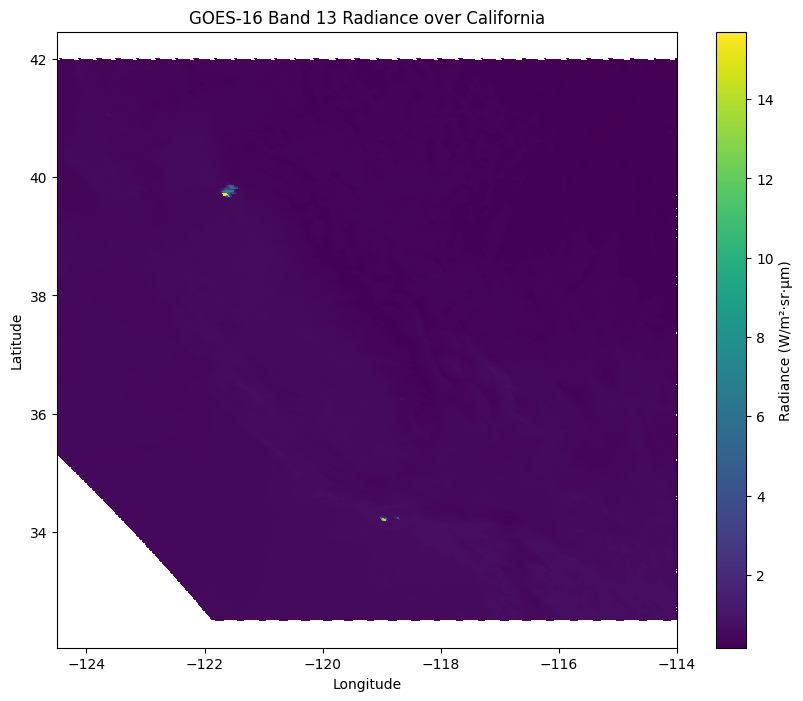

In [ ]:
# Plot radiance for Band 13
plt.figure(figsize=(10, 8))
plt.pcolormesh(
    data_band13_ca['longitude'], data_band13_ca['latitude'], data_band13_ca['Rad'],
    shading='auto', cmap='viridis'
)
plt.colorbar(label="Radiance (W/m²·sr·µm)")
plt.title("GOES-16 Band 13 Radiance over California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()


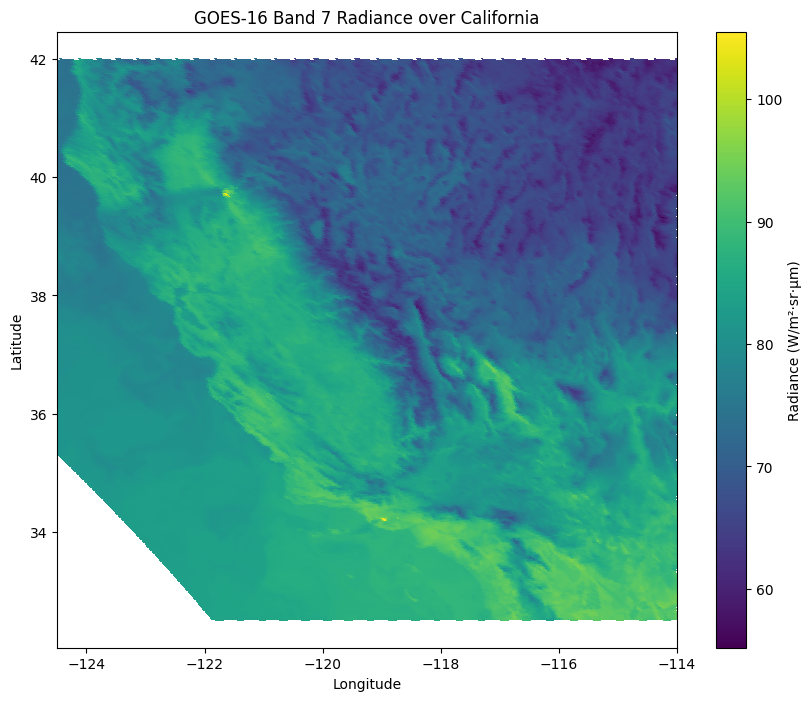

In [ ]:
# Plot radiance for Band 7
plt.figure(figsize=(10, 8))
plt.pcolormesh(
    data_band7_ca['longitude'], data_band7_ca['latitude'], data_band7_ca['Rad'],
    shading='auto', cmap='viridis'
)
plt.colorbar(label="Radiance (W/m²·sr·µm)")
plt.title("GOES-16 Band 7 Radiance over California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

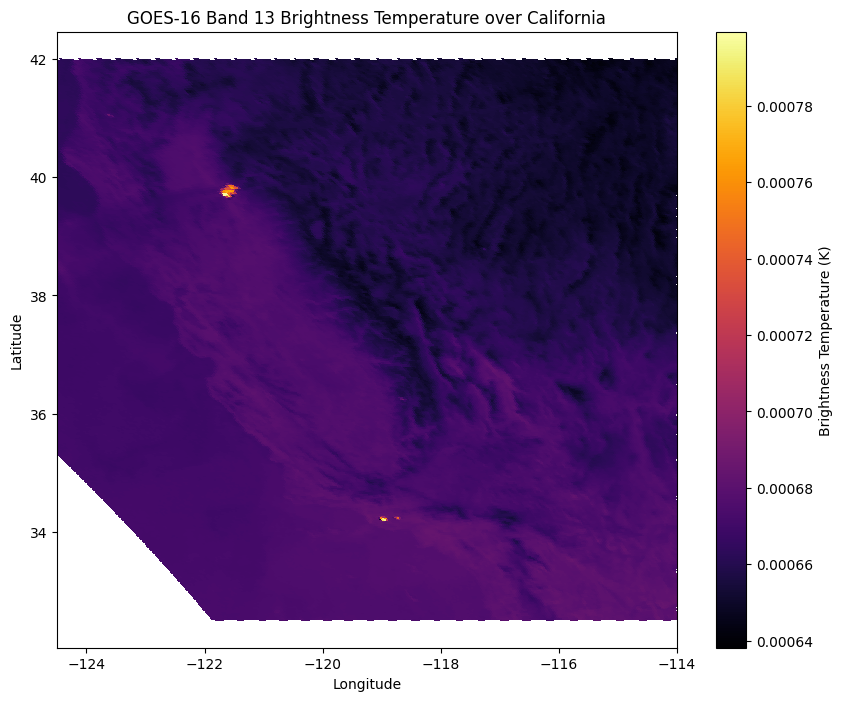

In [ ]:
# Plot brightness temperature for Band 13
plt.figure(figsize=(10, 8))
plt.pcolormesh(
    data_band13_ca['longitude'], data_band13_ca['latitude'], temperature_band13,
    shading='auto', cmap='inferno'
)
plt.colorbar(label="Brightness Temperature (K)")
plt.title("GOES-16 Band 13 Brightness Temperature over California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()


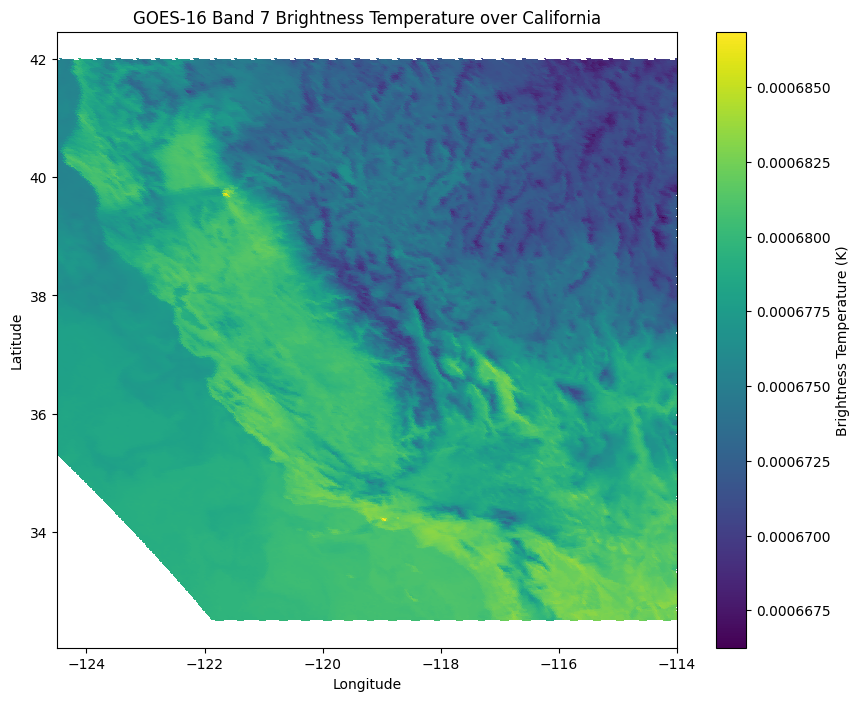

In [ ]:
# Plot brightness temperature for Band 7
plt.figure(figsize=(10, 8))
plt.pcolormesh(
    data_band7_ca['longitude'], data_band7_ca['latitude'], temperature_band7,
    shading='auto', cmap='viridis'
)
plt.colorbar(label="Brightness Temperature (K)")
plt.title("GOES-16 Band 7 Brightness Temperature over California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

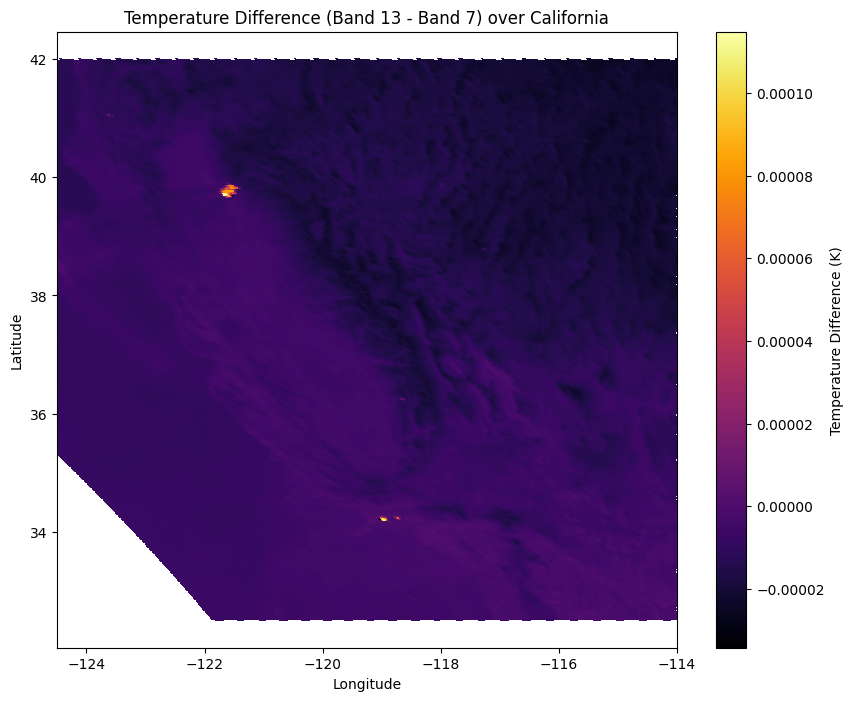

In [ ]:
# Calculate temperature difference
temperature_difference = temperature_band13 - temperature_band7

# Plot temperature difference
plt.figure(figsize=(10, 8))
plt.pcolormesh(
    data_band7_ca['longitude'], data_band7_ca['latitude'], temperature_difference,
    shading='auto', cmap='inferno'
)
plt.colorbar(label="Temperature Difference (K)")
plt.title("Temperature Difference (Band 13 - Band 7) over California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

In [ ]:
# Downscale resolution by averaging over 2x2 grid cells
temperature_difference_reduced = temperature_difference.coarsen(x=2, y=2, boundary='trim').mean()
temperature_difference_reduced

<xarray.DataArray 'Rad' (y: 193, x: 217)> Size: 168kB
array([[           nan,            nan,            nan, ...,
        -2.3167231e-05, -2.2798922e-05, -2.2814638e-05],
       [           nan,            nan,            nan, ...,
        -2.2607506e-05, -2.2704000e-05, -2.2938184e-05],
       [           nan,            nan,            nan, ...,
        -2.2742737e-05, -2.3537898e-05,            nan],
       ...,
       [-6.2189210e-06, -6.5292552e-06, -6.4469059e-06, ...,
                   nan,            nan,            nan],
       [-6.3867337e-06, -6.6203793e-06, -6.6711655e-06, ...,
                   nan,            nan,            nan],
       [-6.3756743e-06, -6.6190551e-06, -6.7963069e-06, ...,
                   nan,            nan,            nan]], dtype=float32)
Coordinates:
  * y          (y) float32 772B 0.1099 0.1098 0.1096 ... 0.08859 0.08848 0.08837
  * x          (x) float32 868B -0.1013 -0.1012 -0.1011 ... -0.07722 -0.07711
    y_image    float32 4B 0.08624
    x_image    float32 4B -0.03136
    latitude   (y, x) float64 335kB 44.26 44.23 44.21 ... 31.68 31.67 31.67
    longitude  (y, x) float64 335kB -138.8 -138.6 -138.4 ... -107.5 -107.4

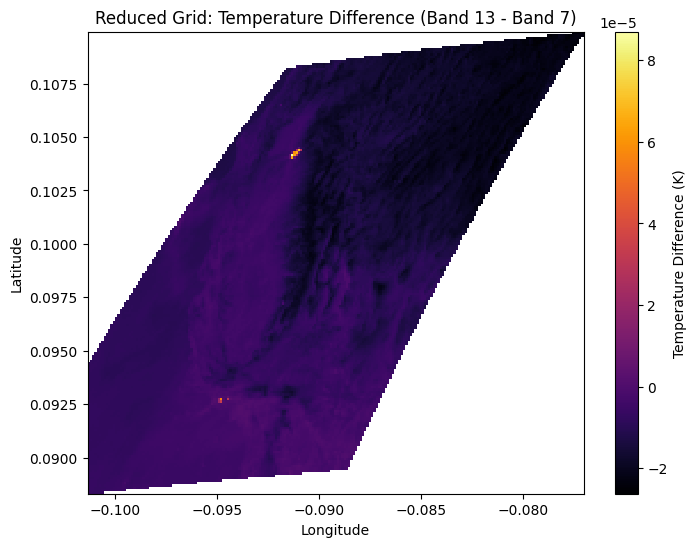

In [ ]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    temperature_difference_reduced['x'],
    temperature_difference_reduced['y'],
    temperature_difference_reduced,
    shading="auto", cmap="inferno"
)
plt.colorbar(label="Temperature Difference (K)")
plt.title("Reduced Grid: Temperature Difference (Band 13 - Band 7)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [ ]:
# Inspect the actual values for latitude ('y') and longitude ('x') in the reduced dataset
x_values = temperature_difference_reduced['x'].values
y_values = temperature_difference_reduced['y'].values

In [ ]:
# Check the order of latitude ('y') values
is_lat_sorted = np.all(np.diff(y_values) < 0)  # True if descending, False if ascending

is_lat_sorted


True

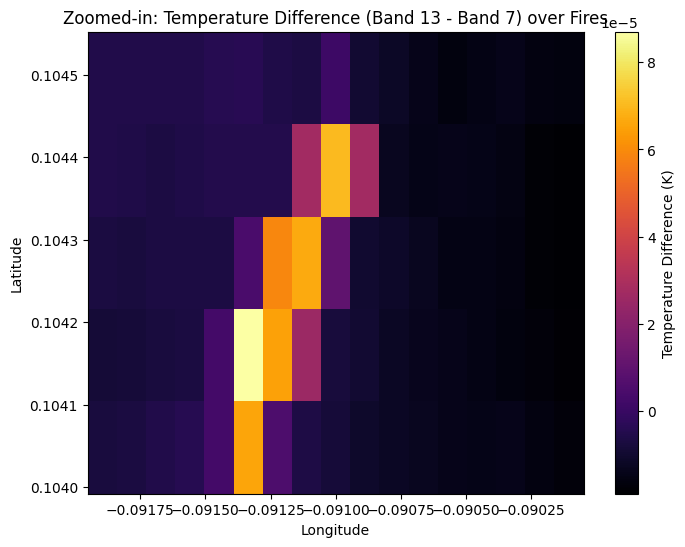

In [ ]:
lon_min, lon_max = -0.092, -0.090
lat_min, lat_max = 0.1045, 0.1040  # Reversed bounds for descending order

# Subset the reduced data with corrected latitude bounds
roi_data = temperature_difference_reduced.sel(x=slice(lon_min, lon_max), y=slice(lat_min, lat_max))

# Plot the zoomed-in region
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    roi_data['x'],
    roi_data['y'],
    roi_data,
    shading="auto", cmap="inferno"
)
plt.colorbar(label="Temperature Difference (K)")
plt.title("Zoomed-in: Temperature Difference (Band 13 - Band 7) over Fires")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

